In [1]:
import os
from pathlib import Path
cwd = Path.cwd()

if cwd.name == "notebooks":
    os.chdir(cwd.parent)

In [2]:
import os
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

from collections import defaultdict

RESULTS_PATH = "data/experiments/single_patching/vitbase_neutrality/single_patching_results.pt" 

results = torch.load(RESULTS_PATH, map_location="cpu", weights_only=False)

print("Top keys:", list(results.keys()))
print("Original keys:", list(results["original"].keys()))
print("Corrupted keys:", list(results["corrupted"].keys()))

print("Patched layers:", list(results["patched"].keys())[:3], "... total:", len(results["patched"]))

orig_probs = results["original"]["final_probs"]
corr_probs = results["corrupted"]["final_probs"]

print("orig_final_probs shape:", np.array(orig_probs).shape)
print("corr_final_probs shape:", np.array(corr_probs).shape)

C = np.array(orig_probs).shape[-1]
print("num classes C =", C)


Top keys: ['original', 'corrupted', 'patched', 'emotion_map']
Original keys: ['metadata', 'final_probs', 'layer_probs']
Corrupted keys: ['metadata', 'final_probs', 'layer_probs']
Patched layers: ['layer_1', 'layer_2', 'layer_3'] ... total: 11
orig_final_probs shape: (1, 6)
corr_final_probs shape: (1, 6)
num classes C = 6


In [ ]:
def to_np(x):
    if x is None:
        return None
    if isinstance(x, np.ndarray):
        return x
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.array(x)

def patch_to_grid(patch_idx, grid_w=14):
    r = patch_idx // grid_w
    c = patch_idx % grid_w
    return r, c

def probs_sanitize(p, eps=1e-12):
    p = to_np(p).astype(np.float64)
    p = np.clip(p, eps, 1.0)
    p = p / p.sum(axis=-1, keepdims=True)
    return p

def kl_div(p, q, eps=1e-12):
    p = probs_sanitize(p, eps=eps)[0]
    q = probs_sanitize(q, eps=eps)[0]
    return float(np.sum(p * (np.log(p) - np.log(q))))

def js_div(p, q, eps=1e-12):
    p = probs_sanitize(p, eps=eps)[0]
    q = probs_sanitize(q, eps=eps)[0]
    m = 0.5 * (p + q)
    return 0.5 * float(np.sum(p * (np.log(p) - np.log(m)))) + 0.5 * float(np.sum(q * (np.log(q) - np.log(m))))

def l1_dist(p, q):
    p = probs_sanitize(p)[0]
    q = probs_sanitize(q)[0]
    return float(np.sum(np.abs(p - q)))

def delta_correct_prob(patched, base, correct_class):
    patched = probs_sanitize(patched)[0]
    base = probs_sanitize(base)[0]
    return float(patched[correct_class] - base[correct_class])


In [4]:
orig_probs = probs_sanitize(results["original"]["final_probs"])
correct_class = int(orig_probs[0].argmax())

print("Chosen correct_class =", correct_class, "(argmax original)")
print("Original top-5 classes:", orig_probs[0].argsort()[-5:][::-1])
print("Original p(correct) =", float(orig_probs[0, correct_class]))


Chosen correct_class = 1 (argmax original)
Original top-5 classes: [1 4 5 3 2]
Original p(correct) = 0.9999999952257552


In [5]:
results['emotion_map']

{0: 'neutrality',
 1: 'happiness',
 2: 'sadness',
 3: 'anger',
 4: 'disgust',
 5: 'fear'}

In [6]:
results["original"]["final_probs"]

array([[1.30018748e-15, 9.99999995e-01, 1.93375107e-15, 1.18826544e-23,
        4.74862290e-09, 2.26218656e-11]])

In [7]:
results["corrupted"]["final_probs"]

array([[1.29963496e-04, 6.69780996e-25, 9.99870037e-01, 2.02042806e-24,
        1.28216090e-24, 8.24437149e-13]])

In [ ]:
results["original"]["final_probs"]

In [8]:
STREAMS = ["block_output", "attention_output", "mlp_activation"]

layer_keys = sorted(results["patched"].keys(), key=lambda s: int(s.split("_")[1]))
L = len(layer_keys)
P = 196  # 14x14

orig_final = probs_sanitize(results["original"]["final_probs"])
corr_final = probs_sanitize(results["corrupted"]["final_probs"])

stream_to_idx = {s:i for i,s in enumerate(STREAMS)}

delta_pcorrect = np.full((L, len(STREAMS), P), np.nan, dtype=np.float64)
kl_to_orig     = np.full((L, len(STREAMS), P), np.nan, dtype=np.float64)
js_to_orig     = np.full((L, len(STREAMS), P), np.nan, dtype=np.float64)
l1_to_orig     = np.full((L, len(STREAMS), P), np.nan, dtype=np.float64)

# Probe-next-layer metrics (same shapes, may contain NaNs for last layer)
probe_delta_pcorrect = np.full((L, len(STREAMS), P), np.nan, dtype=np.float64)
probe_kl_to_orig     = np.full((L, len(STREAMS), P), np.nan, dtype=np.float64)

for li, lk in enumerate(layer_keys):
    layer_dict = results["patched"][lk]
    for s in STREAMS:
        sd = layer_dict.get(s, {})
        si = stream_to_idx[s]
        for pidx in range(P):
            pk = f"patch_{pidx}"
            if pk not in sd:
                continue
            entry = sd[pk]
            pf = entry.get("final_probs", None)
            if pf is None:
                continue

            # final head metrics vs original
            delta_pcorrect[li, si, pidx] = delta_correct_prob(pf, orig_final, correct_class)
            kl_to_orig[li, si, pidx]     = kl_div(pf, orig_final)
            js_to_orig[li, si, pidx]     = js_div(pf, orig_final)
            l1_to_orig[li, si, pidx]     = l1_dist(pf, orig_final)

            # probe next layer (if exists)
            probe = entry.get("probe_next_layer_probs", None)
            if probe is not None:
                probe_delta_pcorrect[li, si, pidx] = delta_correct_prob(probe, orig_final, correct_class)
                probe_kl_to_orig[li, si, pidx]     = kl_div(probe, orig_final)

print("Built matrices with shapes:")
print("delta_pcorrect:", delta_pcorrect.shape)
print("kl_to_orig:", kl_to_orig.shape)


Built matrices with shapes:
delta_pcorrect: (11, 3, 196)
kl_to_orig: (11, 3, 196)


In [9]:
probe_delta_pcorrect.shape

(11, 3, 196)

In [10]:
def show_patch_heatmap(values_196, title="", vmin=None, vmax=None):
    grid = np.full((14,14), np.nan, dtype=np.float64)
    for p in range(196):
        r,c = patch_to_grid(p)
        grid[r,c] = values_196[p]

    plt.figure(figsize=(8,8))
    im = plt.imshow(grid)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.show()

def show_layer_stream_heatmaps(metric_arr, layer_idx, metric_name, vmin=None, vmax=None):
    # metric_arr: [L, S, P]
    for si, s in enumerate(STREAMS):
        vals = metric_arr[layer_idx, si, :]
        show_patch_heatmap(vals, title=f"{metric_name} | layer={layer_idx} | stream={s}", vmin=vmin, vmax=vmax)

def stream_curve(metric_arr, stream, agg="mean_abs"):
    si = stream_to_idx[stream]
    y = []
    for li in range(metric_arr.shape[0]):
        vals = metric_arr[li, si, :]
        vals = vals[np.isfinite(vals)]
        if len(vals)==0:
            y.append(np.nan); continue
        if agg == "mean":
            y.append(float(np.mean(vals)))
        elif agg == "mean_abs":
            y.append(float(np.mean(np.abs(vals))))
        elif agg == "max_abs":
            y.append(float(np.max(np.abs(vals))))
        else:
            raise ValueError("agg must be mean | mean_abs | max_abs")
    return np.array(y)

def plot_layer_curves(metric_arr, metric_name, agg="mean_abs"):
    plt.figure(figsize=(7,4))
    for s in STREAMS:
        y = stream_curve(metric_arr, s, agg=agg)
        plt.plot(np.arange(len(y)), y, marker="o", label=s)
    plt.title(f"{metric_name} vs layer | agg={agg}")
    plt.xlabel("Layer index (0..)")
    plt.ylabel(metric_name)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def top_patches_bar(metric_arr, layer_idx, stream, k=15, metric_name="Δp(correct)"):
    si = stream_to_idx[stream]
    vals = metric_arr[layer_idx, si, :]
    vals = np.where(np.isfinite(vals), vals, -np.inf)
    top_idx = np.argsort(vals)[-k:][::-1]

    plt.figure(figsize=(8,4))
    plt.bar([f"{i}" for i in top_idx], vals[top_idx])
    plt.title(f"Top-{k} patches | layer={layer_idx} | stream={stream} | {metric_name}")
    plt.xlabel("patch_idx (0..195)")
    plt.ylabel(metric_name)
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

def worst_patches_bar(metric_arr, layer_idx, stream, k=15, metric_name="Δp(correct)"):
    si = stream_to_idx[stream]
    vals = metric_arr[layer_idx, si, :]
    vals = np.where(np.isfinite(vals), vals, np.inf)
    worst_idx = np.argsort(vals)[:k]

    plt.figure(figsize=(8,4))
    plt.bar([f"{i}" for i in worst_idx], vals[worst_idx])
    plt.title(f"Worst-{k} patches | layer={layer_idx} | stream={stream} | {metric_name}")
    plt.xlabel("patch_idx (0..195)")
    plt.ylabel(metric_name)
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()


In [11]:
orig = probs_sanitize(results["original"]["final_probs"])[0]
corr = probs_sanitize(results["corrupted"]["final_probs"])[0]

print("Original p(correct) =", float(orig[correct_class]))
print("Corrupted p(correct) =", float(corr[correct_class]))
print("Δ p(correct) (corr-orig) =", float(corr[correct_class] - orig[correct_class]))

print("KL(corr || orig) =", kl_div(corr[None,:], orig[None,:]))
print("JS(corr, orig) =", js_div(corr[None,:], orig[None,:]))
print("L1(corr, orig) =", l1_dist(corr[None,:], orig[None,:]))


Original p(correct) = 0.9999999952257552
Corrupted p(correct) = 9.999999999968241e-13
Δ p(correct) (corr-orig) = -0.9999999952247552
KL(corr || orig) = 27.62972821396837
JS(corr, orig) = 0.6931471805139766
L1(corr, orig) = 1.999999999988


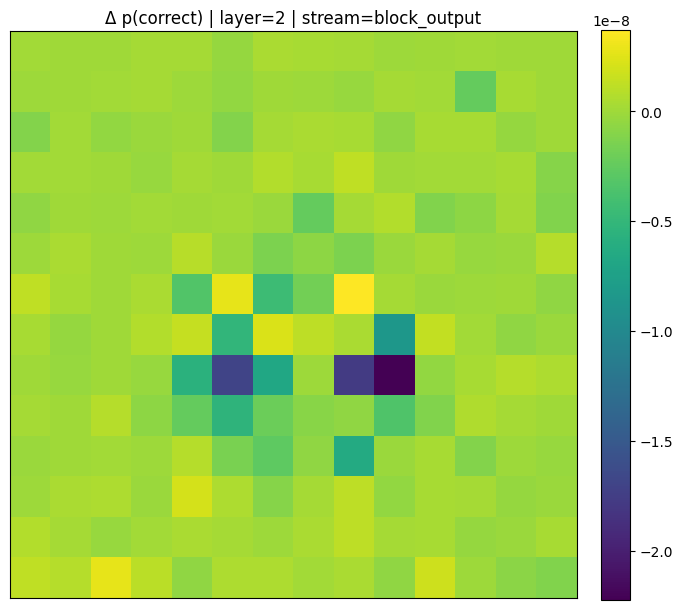

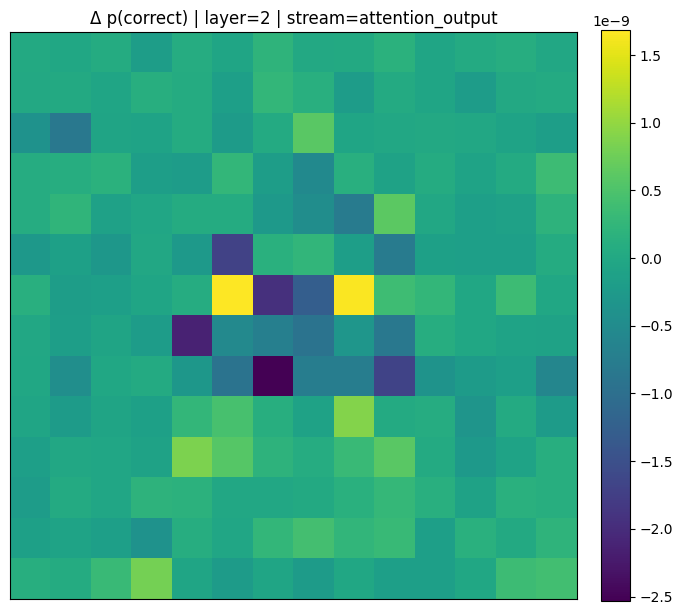

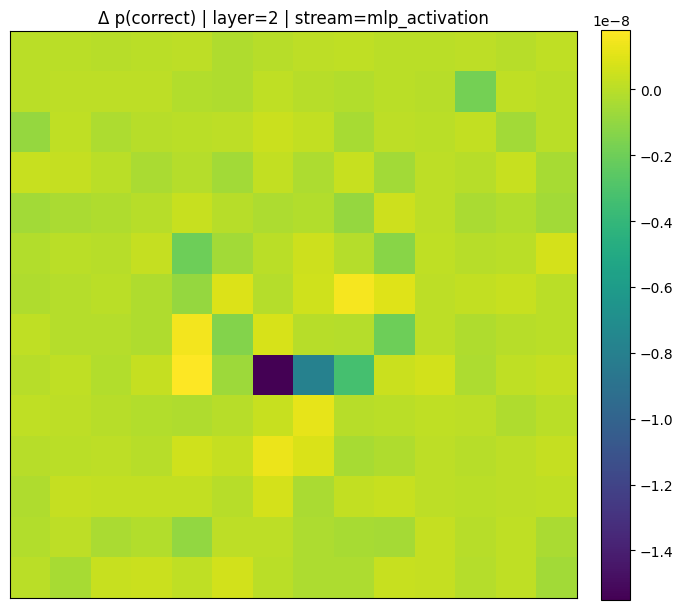

In [12]:
LAYER_TO_VIEW = 2  # change

# Δp(correct): red/blue-ish by default colormap; you can clamp for comparability
show_layer_stream_heatmaps(delta_pcorrect, LAYER_TO_VIEW, "Δ p(correct)")


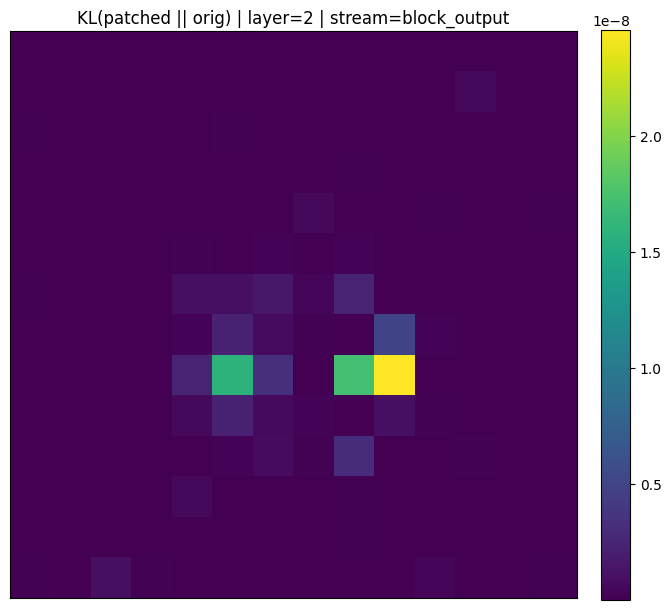

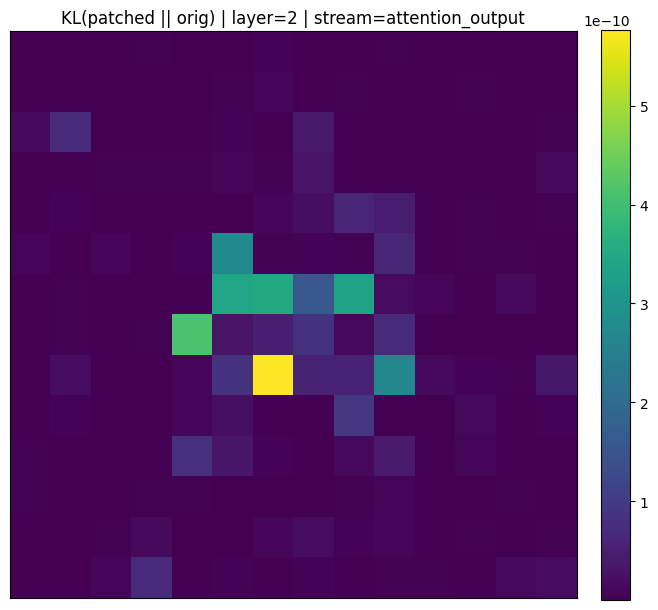

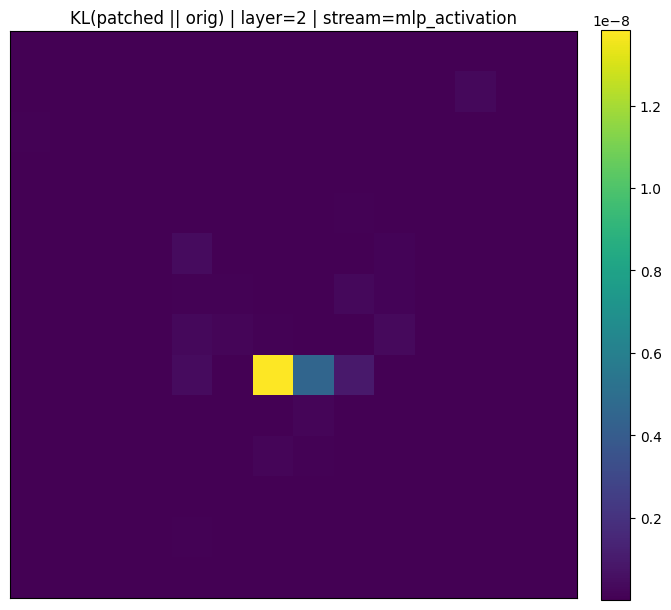

In [13]:

# divergence maps (always >=0)
show_layer_stream_heatmaps(kl_to_orig, LAYER_TO_VIEW, "KL(patched || orig)")



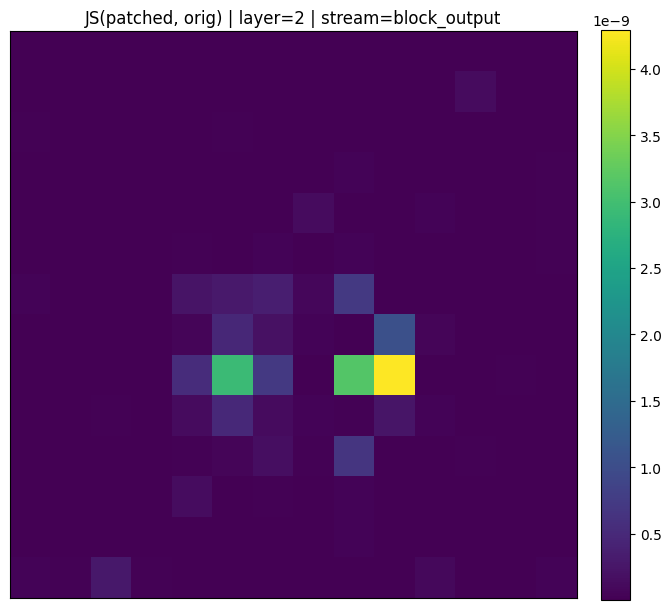

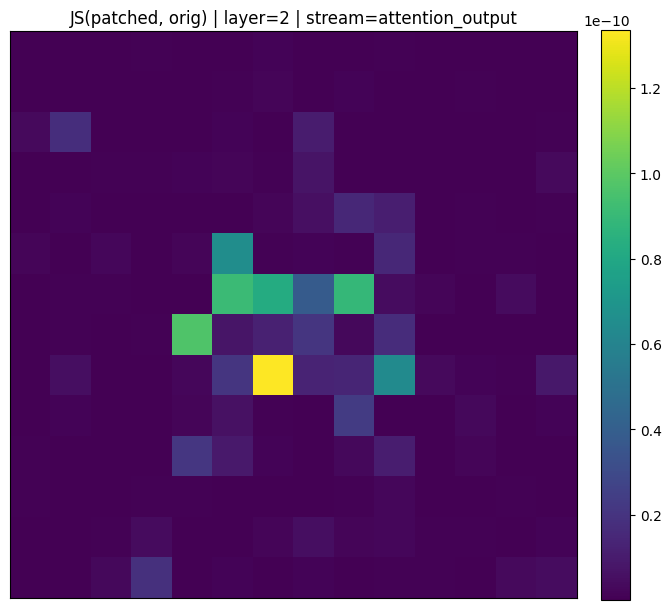

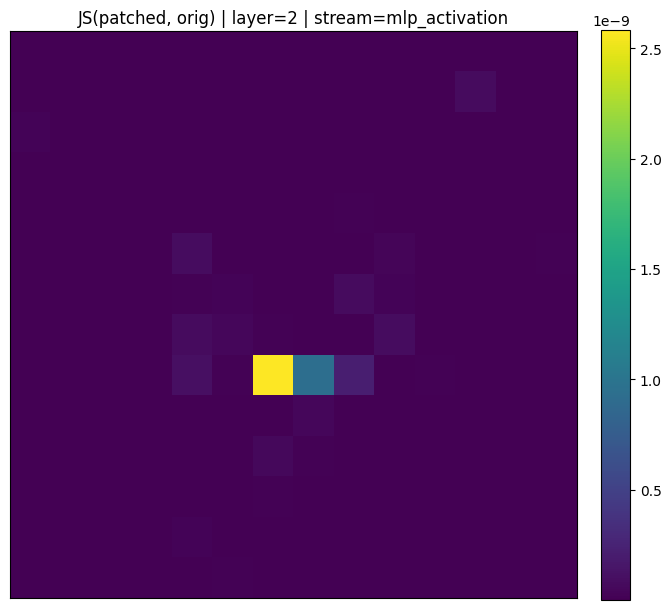

In [14]:
show_layer_stream_heatmaps(js_to_orig, LAYER_TO_VIEW, "JS(patched, orig)")

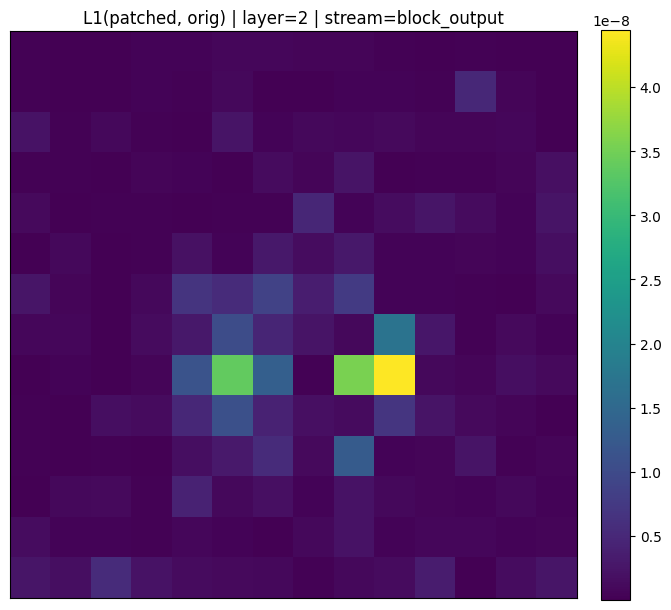

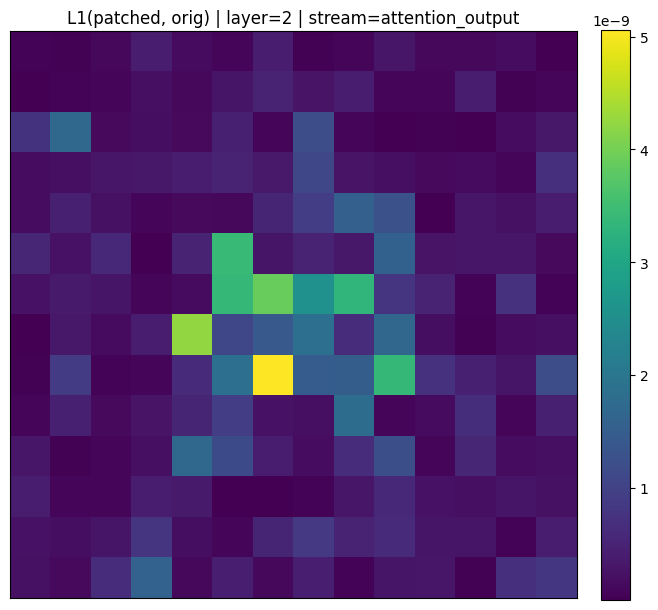

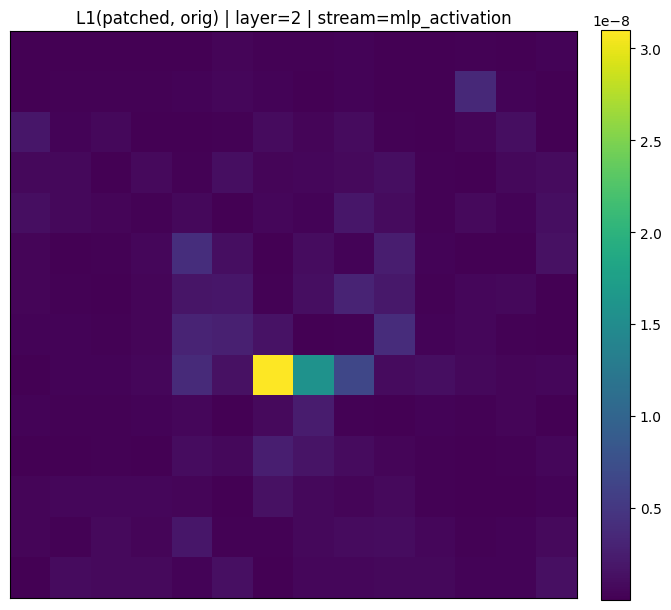

In [15]:
show_layer_stream_heatmaps(l1_to_orig, LAYER_TO_VIEW, "L1(patched, orig)")


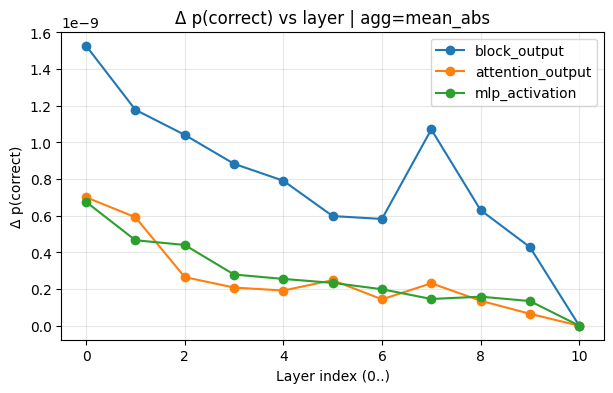

In [16]:
plot_layer_curves(delta_pcorrect, "Δ p(correct)", agg="mean_abs")


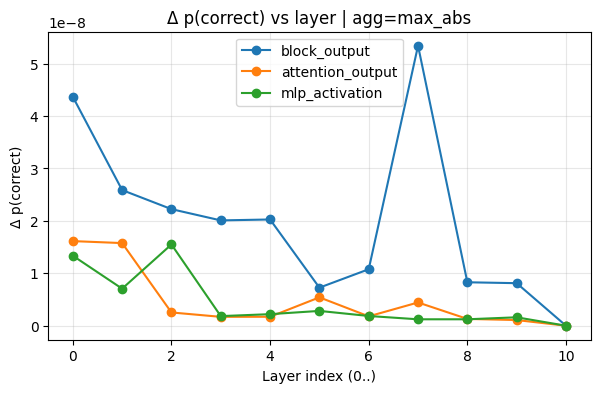

In [17]:
plot_layer_curves(delta_pcorrect, "Δ p(correct)", agg="max_abs")



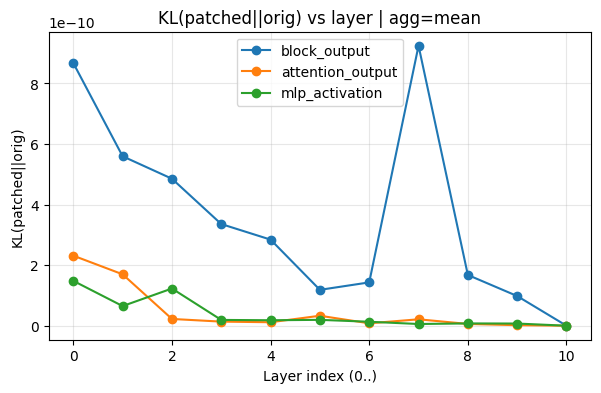

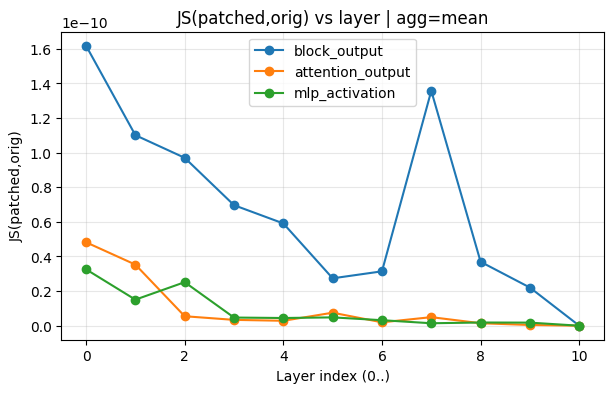

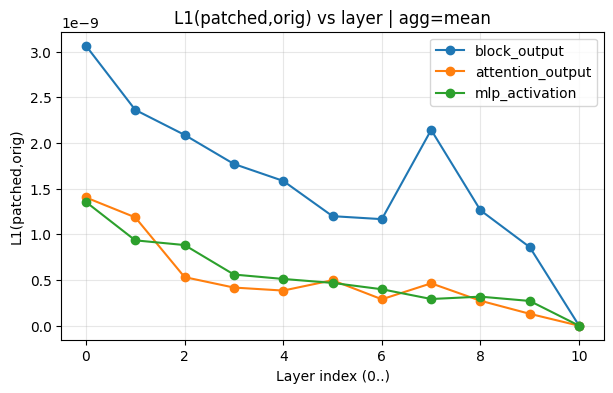

In [18]:
plot_layer_curves(kl_to_orig, "KL(patched||orig)", agg="mean")

plot_layer_curves(js_to_orig, "JS(patched,orig)", agg="mean")
plot_layer_curves(l1_to_orig, "L1(patched,orig)", agg="mean")

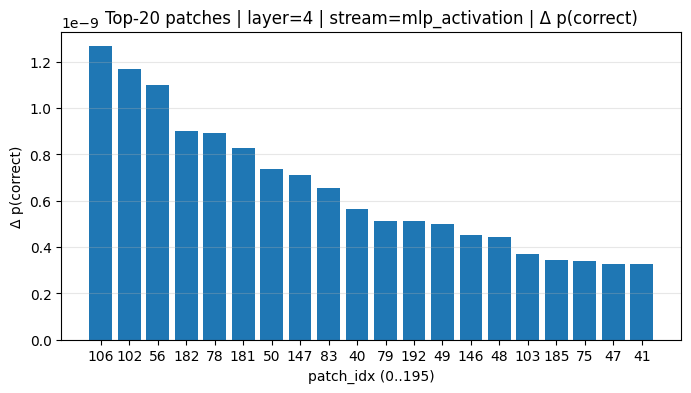

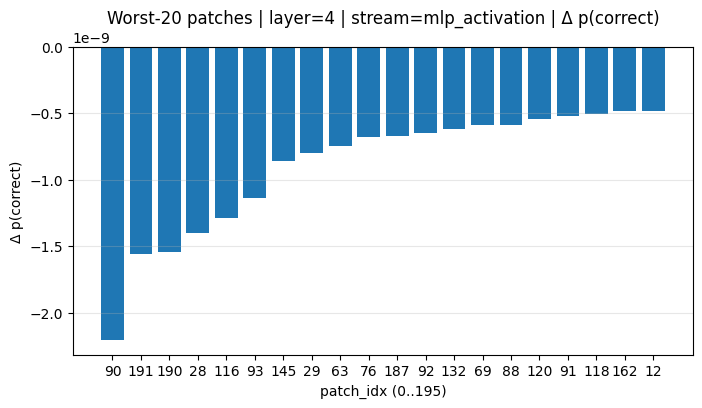

In [19]:
LAYER_TO_VIEW = 4
STREAM_TO_VIEW = "mlp_activation"  # try "mlp_activation", "block_output"

top_patches_bar(delta_pcorrect, LAYER_TO_VIEW, STREAM_TO_VIEW, k=20, metric_name="Δ p(correct)")
worst_patches_bar(delta_pcorrect, LAYER_TO_VIEW, STREAM_TO_VIEW, k=20, metric_name="Δ p(correct)")


In [ ]:
def best_layer(metric_arr, stream, agg="mean_abs"):
    y = stream_curve(metric_arr, stream, agg=agg)
    return int(np.nanargmax(y)), y

for s in STREAMS:
    li, y = best_layer(delta_pcorrect, s, agg="mean_abs")
    print(f"Best layer for stream={s}: layer {li}, score={y[li]:.6f}")


Best layer for stream=block_output: layer 0, score=0.000000
Best layer for stream=attention_output: layer 0, score=0.000000
Best layer for stream=mlp_activation: layer 0, score=0.000000


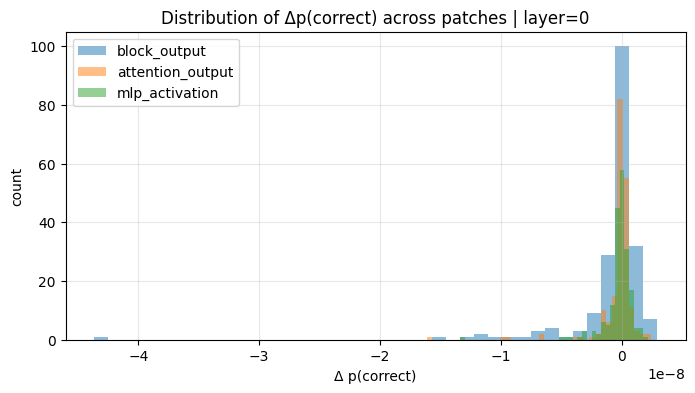

In [23]:
LAYER_TO_VIEW = 0

plt.figure(figsize=(8,4))
for s in STREAMS:
    si = stream_to_idx[s]
    vals = delta_pcorrect[LAYER_TO_VIEW, si, :]
    vals = vals[np.isfinite(vals)]
    plt.hist(vals, bins=40, alpha=0.5, label=s)
plt.title(f"Distribution of Δp(correct) across patches | layer={LAYER_TO_VIEW}")
plt.xlabel("Δ p(correct)")
plt.ylabel("count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


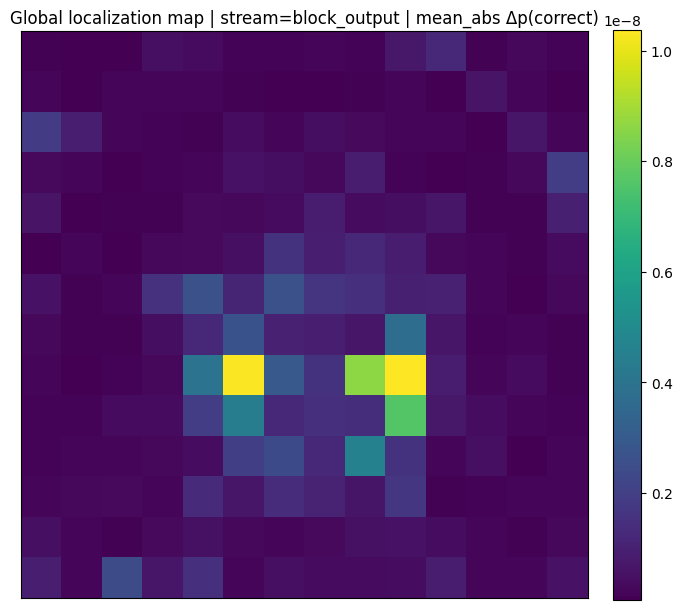

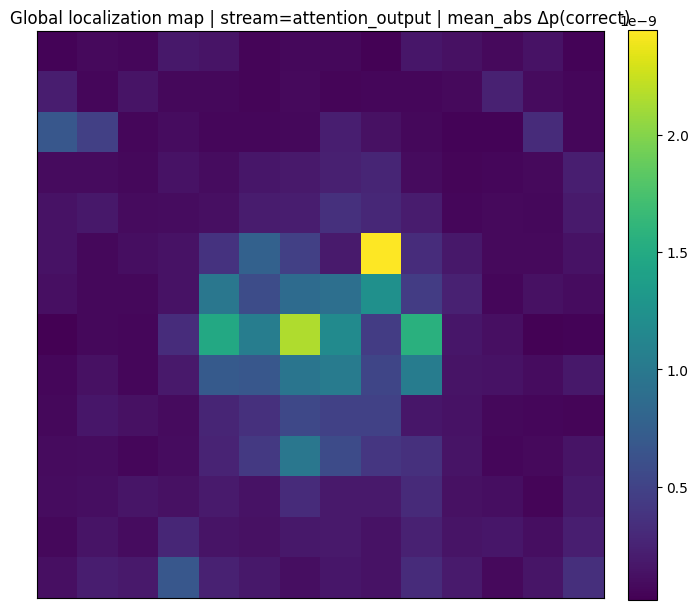

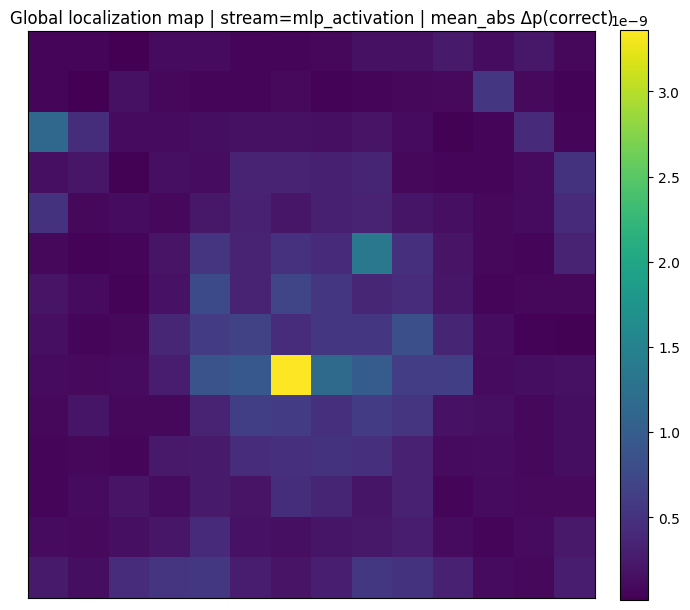

In [ ]:
def aggregate_over_layers(metric_arr, stream, agg="mean_abs"):
    si = stream_to_idx[stream]
    vals = metric_arr[:, si, :]
    if agg == "mean_abs":
        out = np.nanmean(np.abs(vals), axis=0)
    elif agg == "max_abs":
        out = np.nanmax(np.abs(vals), axis=0)
    elif agg == "mean":
        out = np.nanmean(vals, axis=0)
    else:
        raise ValueError("agg must be mean_abs|max_abs|mean")
    return out

for s in STREAMS:
    v = aggregate_over_layers(delta_pcorrect, s, agg="mean_abs")
    show_patch_heatmap(v, title=f"Global localization map | stream={s} | mean_abs Δp(correct)")


# NEXT LATYER PROBAS

In [ ]:
import os, re, math
import numpy as np
import torch
import matplotlib.pyplot as plt

RESULTS_PATH = "data/experiments/single_patching/vitbase_neutrality/single_patching_results.pt"
results = torch.load(RESULTS_PATH, map_location="cpu", weights_only=False)

def _to_np(x):
    if x is None:
        return None
    if isinstance(x, np.ndarray):
        return x
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.array(x)

def get_true_class_index(results):
    md = results.get("original", {}).get("metadata", {})
    for k in ["label", "emotion_id", "target", "y", "class_id", "true_label", "emotion"]:
        if isinstance(md, dict) and k in md:
            v = md[k]
            if isinstance(v, (list, tuple)) and len(v) == 1:
                v = v[0]
            if isinstance(v, (np.integer, int)):
                return int(v)
            if isinstance(v, str):
                emo_map = results.get("emotion_map", {})
                if isinstance(emo_map, dict):
                    inv = {name: idx for idx, name in emo_map.items()}
                    if v in inv:
                        return int(inv[v])
    orig_final = _to_np(results["original"]["final_probs"])
    return int(orig_final[0].argmax())

def list_layers(results):
    layers = []
    for k in results["patched"].keys():
        m = re.match(r"layer_(\d+)", k)
        if m:
            layers.append(int(m.group(1)))
    return sorted(layers)

TRUE_C = get_true_class_index(results)
C = _to_np(results["original"]["final_probs"]).shape[-1]

print("True class index =", TRUE_C, "| num classes =", C)
print("Patched layers:", list_layers(results)[:5], "...")


True class index = 1 | num classes = 6
Patched layers: [1, 2, 3, 4, 5] ...


In [ ]:
STREAMS = ["block_output", "attention_output", "mlp_activation"]

patched_layers = list_layers(results)
max_patch = 196

orig_layer_probs = results["original"]["layer_probs"]

def get_baseline_layerprob(layer_idx_plus1, cls):
    key = f"layer_{layer_idx_plus1}"
    p = _to_np(orig_layer_probs[key])
    return float(p[0, cls])

def get_patched_probeprob(layer_idx, stream, patch_idx, cls):
    layer_key = f"layer_{layer_idx}"
    entry = results["patched"][layer_key][stream][f"patch_{patch_idx}"]
    p = _to_np(entry["probe_next_layer_probs"])
    if p is None:
        return None
    return float(p[0, cls])

def build_delta_matrix_for_stream(stream, cls=TRUE_C):
    ys = []
    rows = []
    for L in patched_layers:
        baseline_key = f"layer_{L+1}"
        if baseline_key not in orig_layer_probs:
            continue

        probe0 = results["patched"][f"layer_{L}"][stream].get("patch_0", {}).get("probe_next_layer_probs", None)
        if probe0 is None:
            continue

        baseline = get_baseline_layerprob(L+1, cls)
        row = np.full((max_patch,), np.nan, dtype=np.float32)
        for pidx in range(max_patch):
            pp = get_patched_probeprob(L, stream, pidx, cls)
            if pp is None:
                continue
            row[pidx] = baseline - pp
        ys.append(L)
        rows.append(row)
    if not rows:
        return None, None
    return np.vstack(rows), ys

delta_mats = {}
y_layers_map = {}

for s in STREAMS:
    M, ys = build_delta_matrix_for_stream(s, cls=TRUE_C)
    delta_mats[s] = M
    y_layers_map[s] = ys
    print(s, "matrix:", None if M is None else M.shape)


block_output matrix: (10, 196)
attention_output matrix: (10, 196)
mlp_activation matrix: (10, 196)


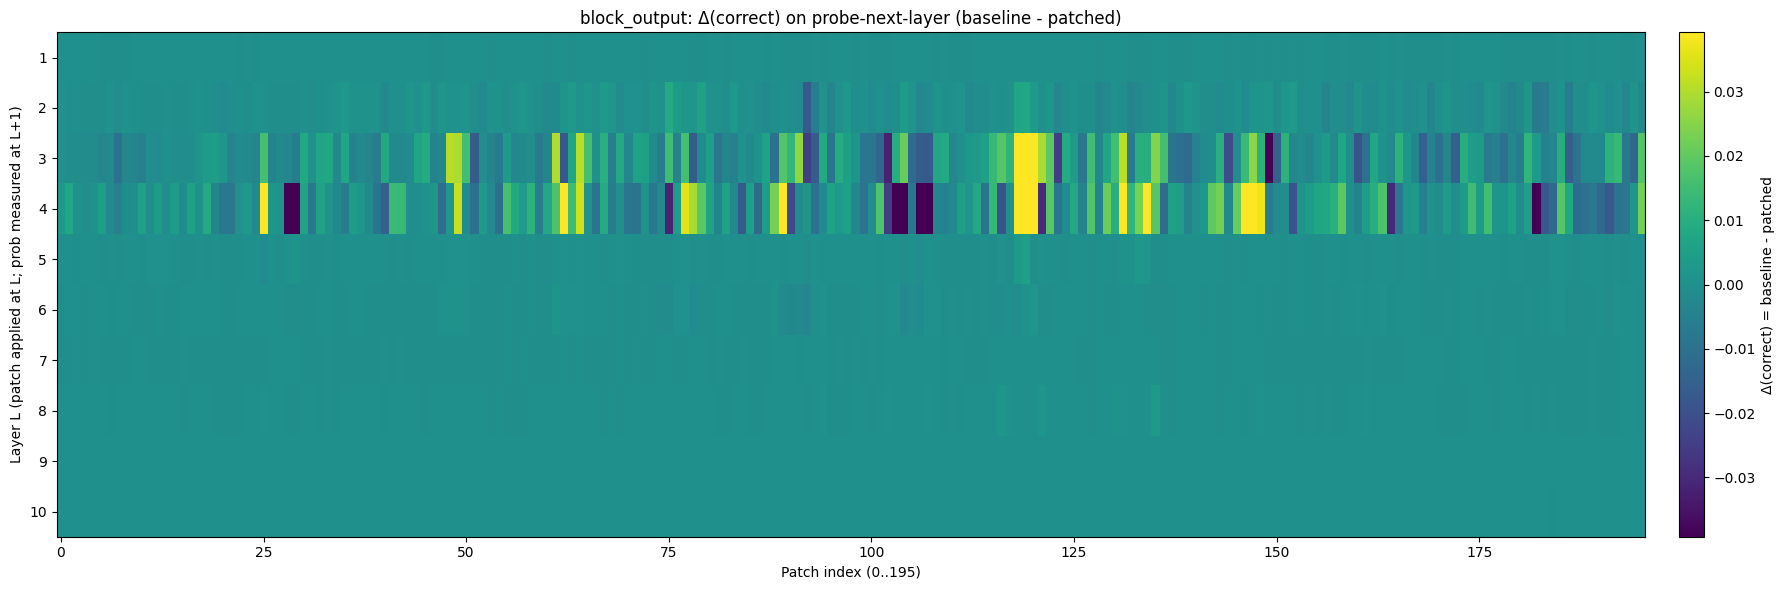

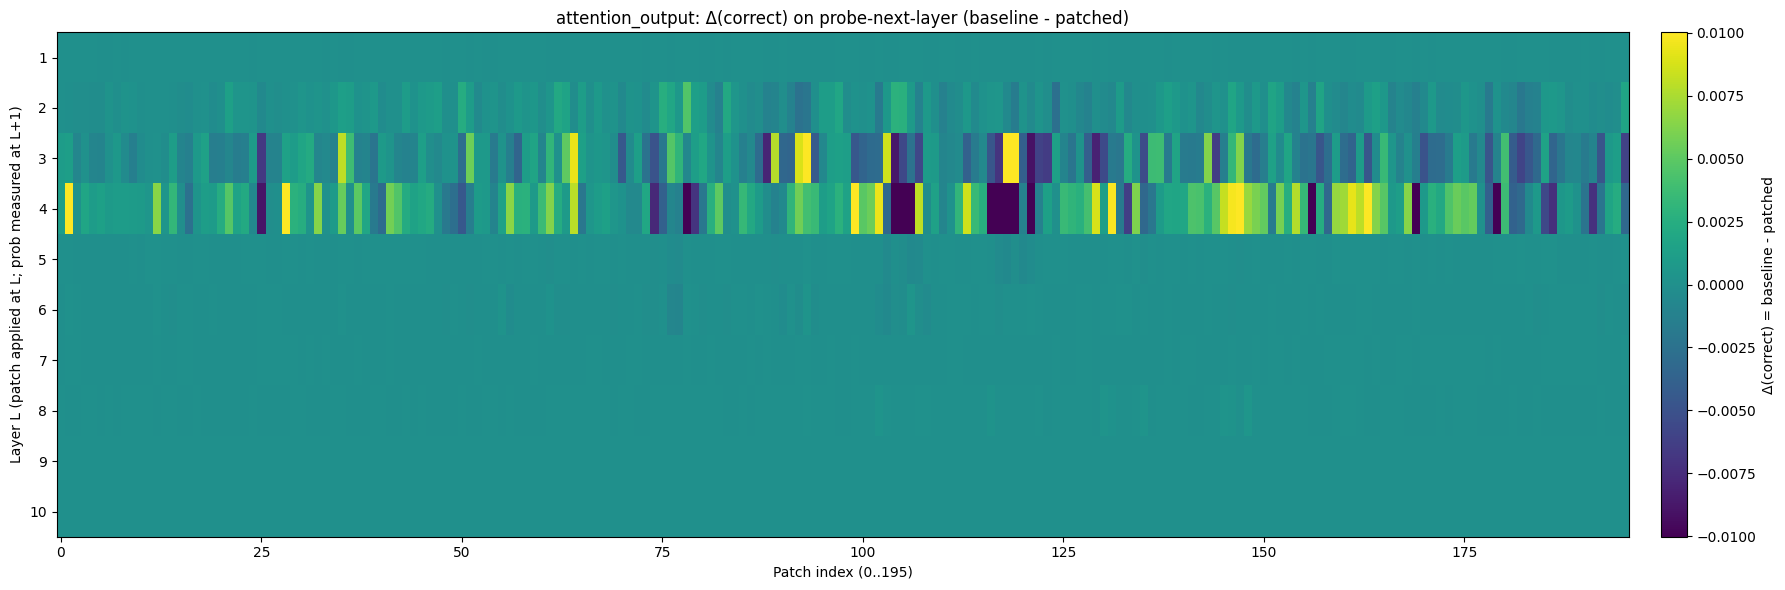

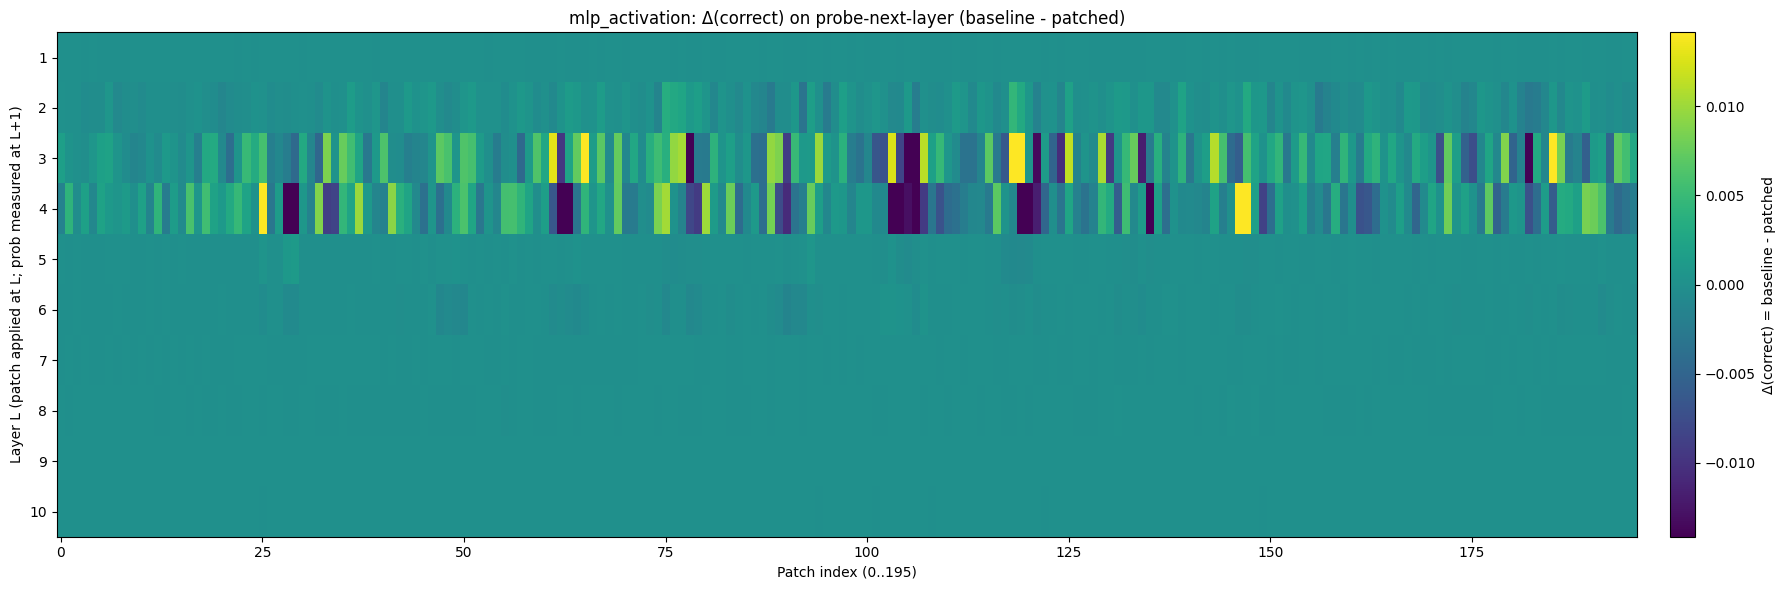

In [ ]:
def plot_heatmap(M, y_layers, title, vlim=None):
    plt.figure(figsize=(18, 6))
    finite = M[np.isfinite(M)]
    if finite.size == 0:
        print("No finite values to plot.")
        return
    if vlim is None:
        q = np.quantile(np.abs(finite), 0.99)
        vlim = q if q > 0 else float(np.max(np.abs(finite)) + 1e-6)

    im = plt.imshow(M, aspect="auto", interpolation="nearest", vmin=-vlim, vmax=vlim)
    plt.colorbar(im, fraction=0.025, pad=0.02, label="Δ(correct) = baseline - patched")
    plt.title(title)
    plt.xlabel("Patch index (0..195)")
    plt.ylabel("Layer L (patch applied at L; prob measured at L+1)")
    plt.yticks(np.arange(len(y_layers)), y_layers)
    plt.tight_layout()
    plt.show()

for s in STREAMS:
    M = delta_mats[s]
    ys = y_layers_map[s]
    if M is None:
        continue
    plot_heatmap(M, ys, title=f"{s}: Δ(correct) on probe-next-layer (baseline - patched)")


In [ ]:
def top_patches(M, y_layers, topk=15):
    pos = np.where(np.isfinite(M), M, 0.0)
    score = pos.mean(axis=0)  # [196]
    order = np.argsort(score)[::-1]
    return [(int(i), float(score[i])) for i in order[:topk]]

for s in STREAMS:
    M = delta_mats[s]
    ys = y_layers_map[s]
    if M is None:
        continue
    top = top_patches(M, ys, topk=20)
    print("\n", s, "TOP patches by mean Δ(correct):")
    for idx, sc in top:
        print(f"  patch_{idx:3d}  meanΔ={sc:.6f}")



 block_output TOP patches by mean Δ(correct):
  patch_119  meanΔ=0.020603
  patch_118  meanΔ=0.019306
  patch_120  meanΔ=0.010961
  patch_131  meanΔ=0.009800
  patch_147  meanΔ=0.009792
  patch_ 89  meanΔ=0.007456
  patch_146  meanΔ=0.006664
  patch_ 64  meanΔ=0.006626
  patch_ 49  meanΔ=0.006451
  patch_ 25  meanΔ=0.006071
  patch_134  meanΔ=0.005976
  patch_ 77  meanΔ=0.005470
  patch_148  meanΔ=0.005076
  patch_ 61  meanΔ=0.004707
  patch_135  meanΔ=0.004627
  patch_122  meanΔ=0.004040
  patch_195  meanΔ=0.003926
  patch_ 48  meanΔ=0.003534
  patch_133  meanΔ=0.003483
  patch_127  meanΔ=0.003222

 attention_output TOP patches by mean Δ(correct):
  patch_147  meanΔ=0.001924
  patch_ 64  meanΔ=0.001705
  patch_  1  meanΔ=0.001520
  patch_ 35  meanΔ=0.001482
  patch_146  meanΔ=0.001479
  patch_ 93  meanΔ=0.001308
  patch_ 28  meanΔ=0.001289
  patch_ 92  meanΔ=0.001185
  patch_ 61  meanΔ=0.001000
  patch_165  meanΔ=0.000900
  patch_143  meanΔ=0.000896
  patch_162  meanΔ=0.000876
  patc

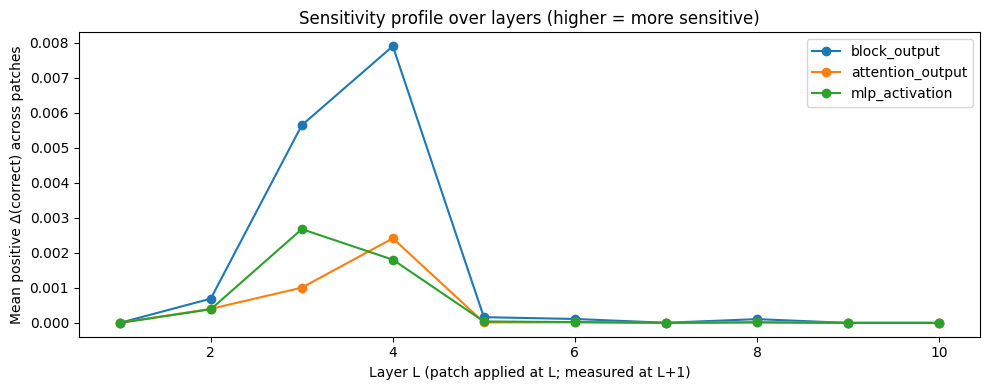

In [ ]:
def layer_profile(M, y_layers):
    pos = np.maximum(M, 0.0)
    vals = np.nanmean(pos, axis=1)
    return np.array(y_layers), vals

plt.figure(figsize=(10,4))
for s in STREAMS:
    M = delta_mats[s]
    ys = y_layers_map[s]
    if M is None:
        continue
    Ls, vals = layer_profile(M, ys)
    plt.plot(Ls, vals, marker="o", label=s)

plt.xlabel("Layer L (patch applied at L; measured at L+1)")
plt.ylabel("Mean positive Δ(correct) across patches")
plt.title("Sensitivity profile over layers (higher = more sensitive)")
plt.legend()
plt.tight_layout()
plt.show()


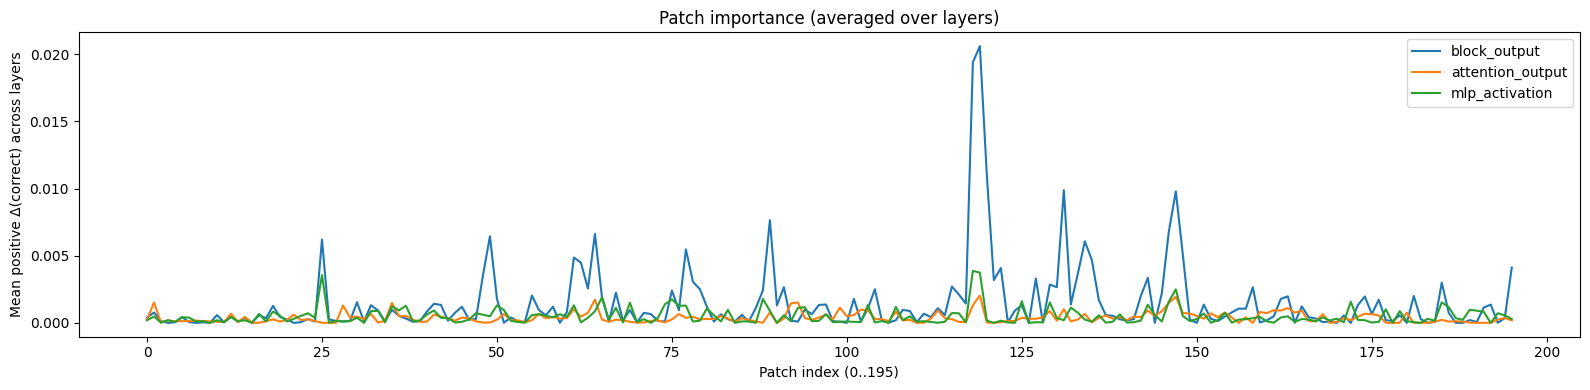

In [31]:
plt.figure(figsize=(16,4))
for s in STREAMS:
    M = delta_mats[s]
    if M is None:
        continue
    pos = np.maximum(M, 0.0)
    patch_score = np.nanmean(pos, axis=0)  # [196]
    plt.plot(np.arange(196), patch_score, label=s)

plt.xlabel("Patch index (0..195)")
plt.ylabel("Mean positive Δ(correct) across layers")
plt.title("Patch importance (averaged over layers)")
plt.legend()
plt.tight_layout()
plt.show()



[block_output] Most harmful: layer L=4, patch=119, Δ(correct)=0.105540 (measured at layer 5)


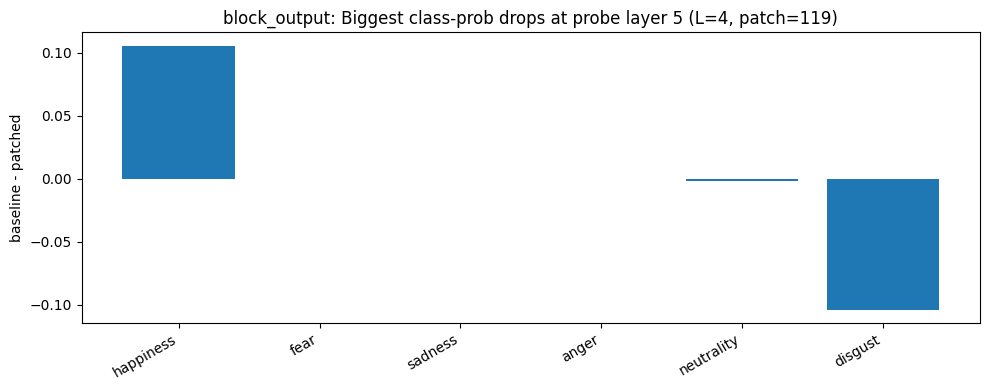


[attention_output] Most harmful: layer L=3, patch=119, Δ(correct)=0.020333 (measured at layer 4)


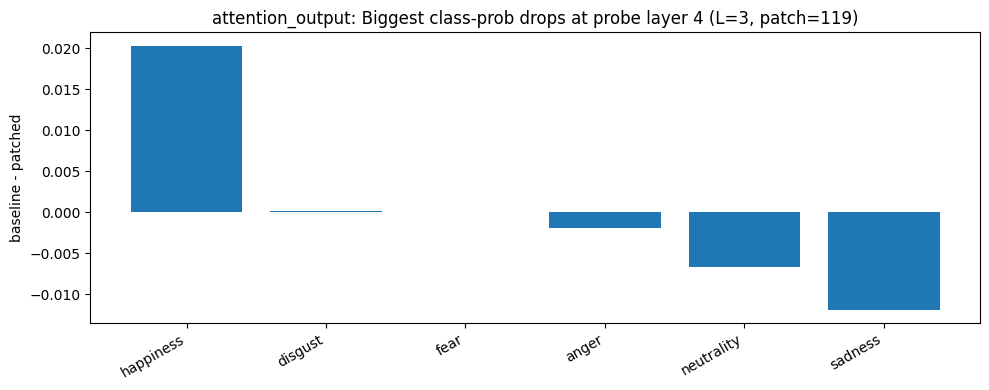


[mlp_activation] Most harmful: layer L=3, patch=119, Δ(correct)=0.034382 (measured at layer 4)


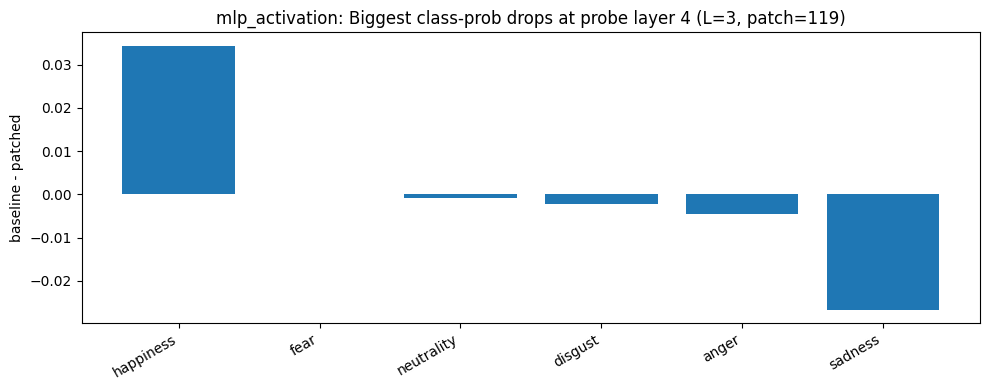

In [ ]:
def argmax_harmful_patch(M, y_layers):
    if M is None:
        return None
    idx = np.nanargmax(M)
    r, c = np.unravel_index(idx, M.shape)
    return y_layers[r], int(c), float(M[r, c])

def get_full_probs_baseline(layer_idx, which="original"):
    p = _to_np(results[which]["layer_probs"][f"layer_{layer_idx}"])
    return p[0]  # [C]

def get_full_probs_patched_probe(layer_L, stream, patch_idx):
    entry = results["patched"][f"layer_{layer_L}"][stream][f"patch_{patch_idx}"]
    p = _to_np(entry["probe_next_layer_probs"])
    return p[0]  # [C]

emo_map = results.get("emotion_map", {})
idx2name = emo_map if isinstance(emo_map, dict) else {i:str(i) for i in range(C)}

for s in STREAMS:
    M = delta_mats[s]
    ys = y_layers_map[s]
    if M is None:
        continue

    best = argmax_harmful_patch(M, ys)
    if best is None:
        continue
    L, pidx, val = best
    probe_layer = L + 1

    base = get_full_probs_baseline(probe_layer, "original")
    patched = get_full_probs_patched_probe(L, s, pidx)

    diff = base - patched

    order = np.argsort(diff)[::-1]
    top = order[:6]

    print(f"\n[{s}] Most harmful: layer L={L}, patch={pidx}, Δ(correct)={val:.6f} (measured at layer {probe_layer})")

    plt.figure(figsize=(10,4))
    xs = np.arange(len(top))
    plt.bar(xs, diff[top])
    plt.xticks(xs, [idx2name.get(int(i), str(i)) for i in top], rotation=30, ha="right")
    plt.ylabel("baseline - patched")
    plt.title(f"{s}: Biggest class-prob drops at probe layer {probe_layer} (L={L}, patch={pidx})")
    plt.tight_layout()
    plt.show()
